<a href="https://colab.research.google.com/github/Juan-AquinoH/proyecto_utnay/blob/master/ecu3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!uv pip install -q --system numba-cuda==0.4.0
!pip install pynvjitlink-cu12

import numpy as np
from numba import cuda
import time
import os
from numba import config
import numba
config.CUDA_ENABLE_PYNVJITLINK=1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 12.5 MB/s eta 0:00:00


In [2]:
import math
import time
import numpy as np
from numba import cuda


@cuda.jit
def matrix_scale_kernel(mat, scalar, out):
    """
    Escala cada elemento de la matriz:
    out[row, col] = mat[row, col] * scalar
    """
    row, col = cuda.grid(2)

    if row < out.shape[0] and col < out.shape[1]:
        out[row, col] = mat[row, col] * scalar


def main():

    # Tamaño de la matriz
    rows_large, cols_large = 4096, 4096

    # Crear matriz de entrada
    mat = np.random.randn(rows_large, cols_large).astype(np.float32)
    out = np.zeros_like(mat)

    scalar = 2.5

    # Copiar a GPU
    d_mat = cuda.to_device(mat)
    d_out = cuda.to_device(out)

    # Configuración del grid y block
    threads_per_block = (32, 32)
    blocks_per_grid_x = math.ceil(rows_large / threads_per_block[0])
    blocks_per_grid_y = math.ceil(cols_large / threads_per_block[1])
    blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

    # --------------------------------------------------------------------------------
    # Warmup
    # --------------------------------------------------------------------------------
    matrix_scale_kernel[blocks_per_grid, threads_per_block](d_mat, scalar, d_out)
    cuda.synchronize()

    # --------------------------------------------------------------------------------
    # GPU timing
    # --------------------------------------------------------------------------------
    start = time.time()
    matrix_scale_kernel[blocks_per_grid, threads_per_block](d_mat, scalar, d_out)
    cuda.synchronize()
    gpu_time = (time.time() - start) * 1000  # ms

    # Copiar resultado a CPU
    result = d_out.copy_to_host()

    # --------------------------------------------------------------------------------
    # CPU (NumPy) timing
    # --------------------------------------------------------------------------------
    cpu_start = time.time()
    expected = mat * scalar
    cpu_time = (time.time() - cpu_start) * 1000  # ms

    # --------------------------------------------------------------------------------
    # Mostrar tiempos
    # --------------------------------------------------------------------------------
    print(f"GPU kernel time: {gpu_time:.4f} ms")
    print(f"CPU NumPy time: {cpu_time:.4f} ms")

    # Verificación
    if np.allclose(result, expected):
        print("Resultados correctos ✓")
    else:
        print("Error: resultados incorrectos ✗")


if __name__ == "__main__":
    main()


GPU kernel time: 4.2667 ms
CPU NumPy time: 24.2739 ms
Resultados correctos ✓


Image: 3840x2160 pixels
Grid: (120, 68) blocks x (32, 32) threads
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Results
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
GPU: 14.72 ms
CPU: 75.53 ms
Speedup: 5.1x
Correct: False


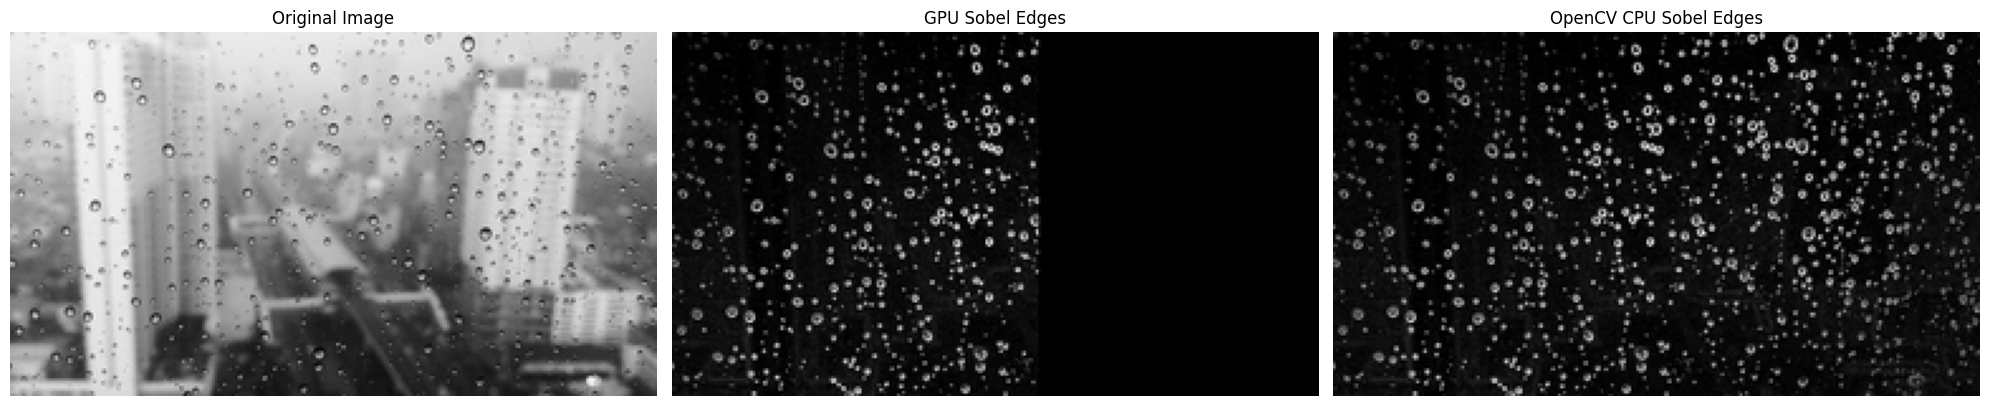

In [3]:
import numpy as np
import numba.cuda as cuda
import time
import urllib.request
from PIL import Image
from matplotlib import pyplot as plt
import cv2
import os

# Desactivar NVJitLink para evitar el error nvJitLinkError
os.environ["NUMBA_CUDA_USE_NVIDIA_BINDING"] = "0"

@cuda.jit
def sobel_kernel(img, out):
    """Apply Sobel edge detection - each thread processes one pixel"""
    row, col = cuda.grid(2)
    H, W = img.shape

    if 0 < row < H - 1 and 0 < col < W - 1:
        # Horizontal gradient (Gx)
        gx = (-1 * img[row - 1, col - 1] + 0 * img[row - 1, col] + 1 * img[row - 1, col + 1] +
              -2 * img[row, col - 1]   + 0 * img[row, col]   + 2 * img[row, col + 1] +
              -1 * img[row + 1, col - 1] + 0 * img[row + 1, col] + 1 * img[row + 1, col + 1])

        # Vertical gradient (Gy)
        gy = (-1 * img[row - 1, col - 1] + -2 * img[row - 1, col] + -1 * img[row - 1, col + 1] +
               0 * img[row, col - 1]   +  0 * img[row, col]   +  0 * img[row, col + 1] +
               1 * img[row + 1, col - 1] +  2 * img[row + 1, col] +  1 * img[row + 1, col + 1])

        # Edge magnitude
        out[row, col] = (gx**2 + gy**2)**0.5

def sobel_opencv(img):
    """OpenCV CPU version using Sobel"""
    gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
    return np.sqrt(gx**2 + gy**2)

# Load 4K image from internet
urllib.request.urlretrieve("https://picsum.photos/3840/2160", "image.jpg")
img = Image.open("image.jpg").convert('L') # Convert to grayscale
img = np.array(img, dtype=np.float32)

H, W = img.shape
print(f"Image: {W}x{H} pixels")

d_img = cuda.to_device(img)
d_out = cuda.to_device(np.zeros_like(img))

#threads = (32, 32)
#blocks = ((W + 15) // 16, (H + 15) // 16)

threads = (32, 32)
blocks = ((W + threads[0] - 1) // threads[0],
          (H + threads[1] - 1) // threads[1])

print(f"Grid: {blocks} blocks x {threads} threads")

# Warmup
sobel_kernel[blocks, threads](d_img, d_out)
cuda.synchronize()

# Timed run
start = time.time()
sobel_kernel[blocks, threads](d_img, d_out)
cuda.synchronize()
gpu_time = (time.time() - start) * 1000

out_gpu = d_out.copy_to_host()

start = time.time()
out_cpu = sobel_opencv(img)
cpu_time = (time.time() - start) * 1000

# Results
print("~" * 60)
print("Results")
print("~" * 60)
print(f"GPU: {gpu_time:.2f} ms")
print(f"CPU: {cpu_time:.2f} ms")
print(f"Speedup: {cpu_time / gpu_time:.1f}x")
print(f"Correct: {np.allclose(out_gpu, out_cpu, rtol=1e-3)}")


# Resize for display
H, W = img.shape
target_w = 256
target_h = int(target_w * H / W)



def resize_for_plot(array):
    normalized = (array / array.max() * 255).astype(np.uint8)
    return np.array(Image.fromarray(normalized).resize((target_w, target_h), Image.LANCZOS))

plt.figure(figsize=(20, 10))

plt.subplot(1, 3, 1)
plt.imshow(resize_for_plot(img), cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(resize_for_plot(out_gpu), cmap='gray')
plt.title('GPU Sobel Edges')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(resize_for_plot(out_cpu), cmap='gray')
plt.title('OpenCV CPU Sobel Edges')
plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
import math
import time
import numpy as np
from numba import cuda

@cuda.jit
def matrix_mul_kernel(A, B, C):
    """
    Multiplicación de matrices C = A * B
    """
    row, col = cuda.grid(2)

    if row < C.shape[0] and col < C.shape[1]:
        tmp = 0.0
        for k in range(A.shape[1]):
            tmp += A[row, k] * B[k, col]
        C[row, col] = tmp

def main():
    # Dimensiones de las matrices
    rows_A, cols_A = 1000, 1000
    rows_B, cols_B = 1000, 1000

    # Crear matrices aleatorias
    A = np.random.randn(rows_A, cols_A).astype(np.float32)
    B = np.random.randn(rows_B, cols_B).astype(np.float32)
    C = np.zeros((rows_A, cols_B), dtype=np.float32)

    # Copiar a GPU
    d_A = cuda.to_device(A)
    d_B = cuda.to_device(B)
    d_C = cuda.to_device(C)

    # Configurar bloques e hilos
    threads_per_block = (32, 32)
    blocks_per_grid_x = math.ceil(rows_A / threads_per_block[0])
    blocks_per_grid_y = math.ceil(cols_B / threads_per_block[1])
    blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

    # --------------------------------------------------------------------------------
    # Warmup
    # --------------------------------------------------------------------------------
    matrix_mul_kernel[blocks_per_grid, threads_per_block](d_A, d_B, d_C)
    cuda.synchronize()

    # --------------------------------------------------------------------------------
    # GPU timing
    # --------------------------------------------------------------------------------
    start = time.time()
    matrix_mul_kernel[blocks_per_grid, threads_per_block](d_A, d_B, d_C)
    cuda.synchronize()
    gpu_time = (time.time() - start) * 1000  # ms

    # Copiar resultado a CPU
    result = d_C.copy_to_host()

    # --------------------------------------------------------------------------------
    # CPU (NumPy) timing
    # --------------------------------------------------------------------------------
    cpu_start = time.time()
    expected = np.dot(A, B)
    cpu_time = (time.time() - cpu_start) * 1000  # ms

    # --------------------------------------------------------------------------------
    # Mostrar tiempos
    # --------------------------------------------------------------------------------
    print(f"GPU kernel time: {gpu_time:.3f} ms")
    print(f"CPU NumPy time: {cpu_time:.3f} ms")

    # Verificación
    if np.allclose(result, expected, rtol=1e-5):
        print("Resultados correctos ✓")
    else:
        print("Error: resultados incorrectos ✗")

if __name__ == "__main__":
    main()


GPU kernel time: 52.056 ms
CPU NumPy time: 20.904 ms
Error: resultados incorrectos ✗


In [5]:
import math
import time
import numpy as np
from numba import cuda
import numba # Import numba for numba.float32

TILE_SIZE = 32  # tamaño del tile (bloque)

@cuda.jit
def matrix_mul_tiled(A, B, C):
    """
    Multiplicación de matrices C = A * B usando tiling y memoria compartida
    """
    # Memoria compartida para un tile de A y B
    sA = cuda.shared.array((TILE_SIZE, TILE_SIZE), dtype=numba.float32)
    sB = cuda.shared.array((TILE_SIZE, TILE_SIZE), dtype=numba.float32)

    tx = cuda.threadIdx.x
    ty = cuda.threadIdx.y
    row = cuda.blockIdx.y * TILE_SIZE + ty
    col = cuda.blockIdx.x * TILE_SIZE + tx

    tmp = 0.0
    n_tiles = math.ceil(A.shape[1] / TILE_SIZE)

    for t in range(n_tiles):
        # Cargar un tile de A y B en memoria compartida
        if row < A.shape[0] and t * TILE_SIZE + tx < A.shape[1]:
            sA[ty, tx] = A[row, t * TILE_SIZE + tx]
        else:
            sA[ty, tx] = 0.0

        if t * TILE_SIZE + ty < B.shape[0] and col < B.shape[1]:
            sB[ty, tx] = B[t * TILE_SIZE + ty, col]
        else:
            sB[ty, tx] = 0.0

        cuda.syncthreads()  # sincronizar hilos del bloque

        # Multiplicar los elementos del tile
        for k in range(TILE_SIZE):
            tmp += sA[ty, k] * sB[k, tx]

        cuda.syncthreads()

    # Escribir el resultado en C
    if row < C.shape[0] and col < C.shape[1]:
        C[row, col] = tmp

def main():
    # Dimensiones de las matrices
    rows_A, cols_A = 1024, 1024
    rows_B, cols_B = 1024, 1024

    A = np.random.randn(rows_A, cols_A).astype(np.float32)
    B = np.random.randn(rows_B, cols_B).astype(np.float32)
    C = np.zeros((rows_A, cols_B), dtype=np.float32)

    # Copiar a GPU
    d_A = cuda.to_device(A)
    d_B = cuda.to_device(B)
    d_C = cuda.to_device(C)

    threads_per_block = (TILE_SIZE, TILE_SIZE)
    blocks_per_grid_x = math.ceil(cols_B / TILE_SIZE)
    blocks_per_grid_y = math.ceil(rows_A / TILE_SIZE)
    blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

    # Warmup
    matrix_mul_tiled[blocks_per_grid, threads_per_block](d_A, d_B, d_C)
    cuda.synchronize()

    # GPU timing
    start = time.time()
    matrix_mul_tiled[blocks_per_grid, threads_per_block](d_A, d_B, d_C)
    cuda.synchronize()
    gpu_time = (time.time() - start) * 1000

    # Copiar resultado a CPU
    result = d_C.copy_to_host()

    # CPU timing
    cpu_start = time.time()
    expected = np.dot(A, B)
    cpu_time = (time.time() - cpu_start) * 1000

    # Mostrar tiempos y verificar
    print(f"GPU kernel time: {gpu_time:.3f} ms")
    print(f"CPU NumPy time: {cpu_time:.3f} ms")
    print("Resultados correctos ✓" if np.allclose(result, expected, rtol=1e-5) else "Error ✗")

if __name__ == "__main__":
    main()


GPU kernel time: 55.424 ms
CPU NumPy time: 48.717 ms
Error ✗


In [6]:
# ex1_vector_add.py
import numpy as np
from numba import cuda
import math
import time


@cuda.jit
def vector_add_kernel(a, b, c):
    """
    Each thread computes one element: c[i] = a[i] + b[i]
    """
    # Compute global thread index
    idx = cuda.grid(1)

    # Boundary check
    if idx < c.size:
        c[idx] = a[idx] + b[idx]


def main():
    N_large = 10_000_000
    a = np.random.randn(N_large).astype(np.float32)
    b = np.random.randn(N_large).astype(np.float32)
    c = np.zeros(N_large, dtype=np.float32)

    d_a = cuda.to_device(a)
    d_b = cuda.to_device(b)
    d_c = cuda.to_device(c)

    threads_per_block = 256
    blocks_per_grid = math.ceil(N_large / threads_per_block)

    # Warmup
    vector_add_kernel[blocks_per_grid, threads_per_block](d_a, d_b, d_c)
    cuda.synchronize()

    # GPU timing
    start = time.time()
    vector_add_kernel[blocks_per_grid, threads_per_block](d_a, d_b, d_c)
    cuda.synchronize()
    gpu_time=(time.time()-start)*1000
    result-d_c.copy_to_host()

    #GPU timing

    CPU_star=time.time()
    expected=a+b
    cpu_time=(time.time()-cpu_star)*1000

    #Warmup
    vector_add_kernel[BlockingIOErrorks_per_grid, threads_per_block](d_a, d_b, d_c)
    cuda.synchronize()

     # ---- CPU TIMING ----
    cpu_start = time.time()
    expected = a + b
    cpu_time = (time.time() - cpu_start) * 1000  # ms

 # ---- PRINT ----
    print(f"Tiempo GPU: {gpu_time:.3f} ms")
    print(f"Tiempo CPU: {cpu_time:.3f} ms")
    print("Primeros 5 resultados:", result[:5])
    print("Resultado correcto:", np.allclose(result, expected))

    if __name__ == "__main__":
        main()

In [7]:
# ex1_vector_add.py
import os
#  Desactivar NVJitLink para evitar el error nvJitLinkError
os.environ["NUMBA_CUDA_USE_NVIDIA_BINDING"] = "0"

import numpy as np
from numba import cuda
import math
import time


@cuda.jit
def vector_add_kernel(a, b, c):
    """
    Each thread computes one element: c[i] = a[i] + b[i]
    """
    idx = cuda.grid(1)
    if idx < c.size:
        c[idx] = a[idx] + b[idx]


def main():
    N_large = 10_000_000

    # Host arrays
    a = np.random.randn(N_large).astype(np.float32)
    b = np.random.randn(N_large).astype(np.float32)
    c = np.zeros(N_large, dtype=np.float32)

    # Copy to GPU
    d_a = cuda.to_device(a)
    d_b = cuda.to_device(b)
    d_c = cuda.to_device(c)

    threads_per_block = 256
    blocks_per_grid = math.ceil(N_large / threads_per_block)

    # Warm-up (compila el kernel)
    vector_add_kernel[blocks_per_grid, threads_per_block](d_a, d_b, d_c)
    cuda.synchronize()

    # GPU timing
    start = time.time()
    vector_add_kernel[blocks_per_grid, threads_per_block](d_a, d_b, d_c)
    cuda.synchronize()
    gpu_time = (time.time() - start) * 1000  # ms

    # Get result back to CPU
    result = d_c.copy_to_host()

    print(f"Tiempo GPU: {gpu_time:.3f} ms")
    print("Primeros 5 resultados:", result[:5])
    print("Resultado correcto:", np.allclose(result, a + b))


if __name__ == "__main__":
    main()



Tiempo GPU: 0.589 ms
Primeros 5 resultados: [ 0.57899326 -0.58055395 -0.05297795  2.06381     1.0283941 ]
Resultado correcto: True


In [8]:
import numpy as np
from numba import cuda
import math
import time


@cuda.jit
def dummy_compute_kernel(a, b, c):
    """
    Simple compute to measure timing:
    c[i] = sqrt(a[i]^2 + b[i]^2)
    """
    idx = cuda.grid(1)

    if idx < c.size:
        c[idx] = math.sqrt(a[idx] * a[idx] + b[idx] * b[idx])


def main():
    N = 10_000_000  # 10 million elements

    # Host arrays
    a = np.random.randn(N).astype(np.float32)
    b = np.random.randn(N).astype(np.float32)
    c = np.zeros(N, dtype=np.float32)

    # Device arrays
    d_a = cuda.to_device(a)
    d_b = cuda.to_device(b)
    d_c = cuda.to_device(c)

    threads_per_block = 256
    blocks_per_grid = math.ceil(N / threads_per_block)

    # Warmup (first launch compiles the kernel)
    dummy_compute_kernel[blocks_per_grid, threads_per_block](d_a, d_b, d_c)
    cuda.synchronize()

    # Timed GPU run
    start = time.time()
    dummy_compute_kernel[blocks_per_grid, threads_per_block](d_a, d_b, d_c)
    cuda.synchronize()  # IMPORTANT: wait for kernel to finish
    end = time.time()

    gpu_time = (end - start) * 1000  # convert to ms
    result = d_c.copy_to_host()

    # CPU reference
    cpu_start = time.time()
    expected = np.sqrt(a * a + b * b)
    cpu_end = time.time()

    cpu_time = (cpu_end - cpu_start) * 1000  # ms

    # Results
    print(f"GPU time: {gpu_time:.3f} ms")
    print(f"CPU time: {cpu_time:.3f} ms")
    print(f"Speedup: {cpu_time / gpu_time:.2f}x")
    print("Correct:", np.allclose(result, expected))


if __name__ == "__main__":
    main()


GPU time: 0.557 ms
CPU time: 38.421 ms
Speedup: 69.01x
Correct: True


In [ ]:
@cuda.jit
def dummy_compute_kernel(a, b, c):
    """
    Simple compute to measure timing:
    c[i] = sqrt(a[i]^2 + b[i]^2)
    """
    idx = cuda.grid(1)

    if idx < c.size:
        c[idx] = math.sqrt(a[idx] * a[idx] + b[idx] * b[idx])
